In [3]:
data_location = '../data/processed/my_fav_data.csv'

In [5]:
import pandas as pd
df = pd.read_csv(data_location)
df.head()

,Год,Регистрационный номер,"Возраст компании, лет",Вид деятельности/отрасль,"Выручка, RUB","Коэффициент быстрой ликвидности, %","Коэффициент обеспеченности собственными оборотными средствами, %","Коэффициент оборачиваемости совокупных активов, %","Коэффициент покрытия процентов по EBIT, %","Коэффициент текущей ликвидности, %",...,"Соотношение совокупного долга к капиталу, %",next_year_liqudation,ogrn_str,region_code,Регион,ВРП_на_душу,USD_RUB_средневзвешенный,Индекс_предпринимательской_уверенности,Ключевая_ставка_средняя,log_Выручка
0,2015,1.020101e+12,34.0,Деятельность по предоставлению мест для кратко...,13289000.0,0.0682,-5.7193,0.210800,1.0,8.8395,...,-3.4809,0,1020100696373,1,Республика Адыгея,230047.1,60.96,-6.8,12.54,16.402447
1,2016,1.020101e+12,34.0,Деятельность по предоставлению мест для кратко...,9406000.0,0.0514,-6.2659,0.153200,1.0,10.3270,...,-3.4809,0,1020100696373,1,Республика Адыгея,230047.1,67.03,-6.8,10.54,16.056858
2,2017,1.020101e+12,34.0,Деятельность по предоставлению мест для кратко...,8739000.0,0.6114,-5.9025,0.145700,1.0,14.3990,...,-3.4809,0,1020100696373,1,Республика Адыгея,232839.8,58.35,-4.0,9.04,15.983306
3,2018,1.020101e+12,34.0,Деятельность по предоставлению мест для кратко...,2565000.0,0.5672,-6.1230,0.049742,1.0,20.2726,...,-3.3136,0,1020100696373,1,Республика Адыгея,252776.7,62.71,-2.5,7.42,14.757469
4,2019,1.020101e+12,34.0,Деятельность по предоставлению мест для кратко...,2370000.0,0.4694,-6.5062,0.049742,1.0,30.4548,...,-2.6833,0,1020100696373,1,Республика Адыгея,272001.2,64.74,-3.0,7.25,14.678401


In [6]:
df.shape

(31996, 25)

In [7]:
df.columns.tolist()

['Год',
 'Регистрационный номер',
 'Возраст компании, лет',
 'Вид деятельности/отрасль',
 'Выручка, RUB',
 'Коэффициент быстрой ликвидности, %',
 'Коэффициент обеспеченности собственными оборотными средствами, %',
 'Коэффициент оборачиваемости совокупных активов, %',
 'Коэффициент покрытия процентов по EBIT, %',
 'Коэффициент текущей ликвидности, %',
 'Оборачиваемость дебиторской задолженности, разы',
 'Оборачиваемость кредиторской задолженности, разы',
 'Рентабельность активов (ROA), %',
 'Рентабельность капитала (ROE), %',
 'Рентабельность продаж, %',
 'Соотношение совокупного долга к капиталу, %',
 'next_year_liqudation',
 'ogrn_str',
 'region_code',
 'Регион',
 'ВРП_на_душу',
 'USD_RUB_средневзвешенный',
 'Индекс_предпринимательской_уверенности',
 'Ключевая_ставка_средняя',
 'log_Выручка']

In [8]:
"""
Pooled логистические регрессии для предсказания ликвидации компаний
Два варианта: без категориальных и с топ-10 рискованных категорий
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2

from sklearn.model_selection import GroupShuffleSplit, GridSearchCV, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Установка seed для воспроизводимости
np.random.seed(42)

print("="*80)
print("ПОСТРОЕНИЕ POOLED ЛОГИСТИЧЕСКИХ РЕГРЕССИЙ ДЛЯ КРЕДИТНОГО РИСКА")
print("="*80)

ПОСТРОЕНИЕ POOLED ЛОГИСТИЧЕСКИХ РЕГРЕССИЙ ДЛЯ КРЕДИТНОГО РИСКА


In [9]:
# ============================================================================
# 1. ПОДГОТОВКА ДАННЫХ
# ============================================================================
print("\n[1/6] Подготовка данных...")

# Определение числовых признаков (исключая ID, целевую переменную и категориальные)
numeric_features = [
    'Возраст компании, лет',
    'Выручка, RUB',
    'Коэффициент быстрой ликвидности, %',
    'Коэффициент обеспеченности собственными оборотными средствами, %',
    'Коэффициент оборачиваемости совокупных активов, %',
    'Коэффициент покрытия процентов по EBIT, %',
    'Коэффициент текущей ликвидности, %',
    'Оборачиваемость дебиторской задолженности, разы',
    'Оборачиваемость кредиторской задолженности, разы',
    'Рентабельность активов (ROA), %',
    'Рентабельность капитала (ROE), %',
    'Рентабельность продаж, %',
    'Соотношение совокупного долга к капиталу, %',
    'ВРП_на_душу',
    'USD_RUB_средневзвешенный',
    'Индекс_предпринимательской_уверенности',
    'Ключевая_ставка_средняя',
    'log_Выручка'
]

categorical_features = ['Регион', 'Вид деятельности/отрасль']
target = 'next_year_liqudation'
group_col = 'ogrn_str'

# Удаление строк с пропусками
df_clean = df.dropna(subset=numeric_features + categorical_features + [target, group_col])
print(f"Размер датасета после очистки: {df_clean.shape}")
print(f"Доля дефолтов: {df_clean[target].mean():.2%}")


[1/6] Подготовка данных...
Размер датасета после очистки: (31996, 25)
Доля дефолтов: 3.31%


In [10]:
# ============================================================================
# 2. РАЗДЕЛЕНИЕ НА TRAIN/TEST С GROUP SHUFFLE SPLIT
# ============================================================================
print("\n[2/6] Разделение выборки (GroupShuffleSplit)...")

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df_clean, groups=df_clean[group_col]))

train_data = df_clean.iloc[train_idx].copy()
test_data = df_clean.iloc[test_idx].copy()

print(f"Train размер: {train_data.shape}, дефолтов: {train_data[target].mean():.2%}")
print(f"Test размер: {test_data.shape}, дефолтов: {test_data[target].mean():.2%}")

X_train_num = train_data[numeric_features]
X_test_num = test_data[numeric_features]
y_train = train_data[target]
y_test = test_data[target]
groups_train = train_data[group_col]


[2/6] Разделение выборки (GroupShuffleSplit)...
Train размер: (25598, 25), дефолтов: 3.38%
Test размер: (6398, 25), дефолтов: 3.02%


In [11]:
# ============================================================================
# 3. МОДЕЛЬ 1: БЕЗ КАТЕГОРИАЛЬНЫХ (ТОЛЬКО ЧИСЛОВЫЕ)
# ============================================================================
print("\n[3/6] Обучение Модели 1 (без категориальных)...")

# Масштабирование
scaler1 = StandardScaler()
X_train_scaled = scaler1.fit_transform(X_train_num)
X_test_scaled = scaler1.transform(X_test_num)

# GridSearch с GroupKFold и L1-регуляризацией
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
group_kfold = GroupKFold(n_splits=5)

lr1 = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42)
grid1 = GridSearchCV(lr1, param_grid, cv=group_kfold, scoring='roc_auc', n_jobs=-1)
grid1.fit(X_train_scaled, y_train, groups=groups_train)

print(f"Лучшие параметры Модели 1: {grid1.best_params_}")
print(f"Лучший AUC на CV: {grid1.best_score_:.4f}")

# Финальная модель
model1 = grid1.best_estimator_
y_train_pred1 = model1.predict_proba(X_train_scaled)[:, 1]
y_test_pred1 = model1.predict_proba(X_test_scaled)[:, 1]


[3/6] Обучение Модели 1 (без категориальных)...
Лучшие параметры Модели 1: {'C': 100}
Лучший AUC на CV: 0.9157


In [12]:
# ============================================================================
# 4. МОДЕЛЬ 2: С ТОП-10 РИСКОВАННЫХ КАТЕГОРИЙ
# ============================================================================
print("\n[4/6] Обучение Модели 2 (с топ-10 рискованных категорий)...")

def create_top_risk_categories(train_df, test_df, cat_col, target_col, top_n=10):
    """Создание топ-N рискованных категорий + Other"""
    # Расчет доли дефолтов по категориям на train
    risk_rates = train_df.groupby(cat_col)[target_col].agg(['mean', 'count'])
    risk_rates = risk_rates[risk_rates['count'] >= 10]  # Минимум 10 наблюдений
    top_categories = risk_rates.nlargest(top_n, 'mean').index.tolist()
    
    # Создание новой категориальной переменной
    train_cat = train_df[cat_col].apply(lambda x: x if x in top_categories else 'Other')
    test_cat = test_df[cat_col].apply(lambda x: x if x in top_categories else 'Other')
    
    return train_cat, test_cat, top_categories

# Создание топ-10 категорий для регионов и отраслей
train_region, test_region, top_regions = create_top_risk_categories(
    train_data, test_data, 'Регион', target, top_n=10
)
train_industry, test_industry, top_industries = create_top_risk_categories(
    train_data, test_data, 'Вид деятельности/отрасль', target, top_n=10
)

print(f"Топ-10 рискованных регионов: {top_regions[:3]}...")
print(f"Топ-10 рискованных отраслей: {top_industries[:3]}...")

# One-hot encoding
train_region_dummies = pd.get_dummies(train_region, prefix='Region', drop_first=False)
test_region_dummies = pd.get_dummies(test_region, prefix='Region', drop_first=False)
train_industry_dummies = pd.get_dummies(train_industry, prefix='Industry', drop_first=False)
test_industry_dummies = pd.get_dummies(test_industry, prefix='Industry', drop_first=False)

# Выравнивание столбцов
test_region_dummies = test_region_dummies.reindex(columns=train_region_dummies.columns, fill_value=0)
test_industry_dummies = test_industry_dummies.reindex(columns=train_industry_dummies.columns, fill_value=0)

# Объединение с числовыми признаками
X_train2 = pd.concat([
    pd.DataFrame(X_train_scaled, columns=numeric_features, index=train_data.index),
    train_region_dummies,
    train_industry_dummies
], axis=1)

X_test2 = pd.concat([
    pd.DataFrame(X_test_scaled, columns=numeric_features, index=test_data.index),
    test_region_dummies,
    test_industry_dummies
], axis=1)

# GridSearch для модели 2
lr2 = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42)
grid2 = GridSearchCV(lr2, param_grid, cv=group_kfold, scoring='roc_auc', n_jobs=-1)
grid2.fit(X_train2, y_train, groups=groups_train)

print(f"Лучшие параметры Модели 2: {grid2.best_params_}")
print(f"Лучший AUC на CV: {grid2.best_score_:.4f}")

# Финальная модель
model2 = grid2.best_estimator_
y_train_pred2 = model2.predict_proba(X_train2)[:, 1]
y_test_pred2 = model2.predict_proba(X_test2)[:, 1]


[4/6] Обучение Модели 2 (с топ-10 рискованных категорий)...
Топ-10 рискованных регионов: ['Еврейская автономная область', 'Смоленская область', 'Республика Карелия']...
Топ-10 рискованных отраслей: ['Производство пластмассовых изделий, используемых в строительстве', 'Деятельность агентств по подбору персонала', 'Консультирование по вопросам коммерческой деятельности и управления']...
Лучшие параметры Модели 2: {'C': 1}
Лучший AUC на CV: 0.9196


In [13]:
# ============================================================================
# 5. ОЦЕНКА МОДЕЛЕЙ
# ============================================================================
print("\n[5/6] Оценка качества моделей...")

def calculate_metrics(y_true, y_pred):
    """Расчет метрик качества"""
    auc = roc_auc_score(y_true, y_pred)
    gini = 2 * auc - 1
    
    # KS-статистика
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    ks = np.max(tpr - fpr)
    
    return {'AUC': auc, 'Gini': gini, 'KS': ks}

def hosmer_lemeshow_test(y_true, y_pred, n_bins=10):
    """Тест Хосмера-Лемешева"""
    # Разбиение на группы по предсказанным вероятностям
    df_hl = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
    df_hl['bin'] = pd.qcut(df_hl['y_pred'], q=n_bins, duplicates='drop')
    
    # Подсчет наблюдаемых и ожидаемых
    grouped = df_hl.groupby('bin', observed=True).agg({
        'y_true': ['sum', 'count'],
        'y_pred': 'mean'
    })
    
    observed = grouped['y_true']['sum'].values
    total = grouped['y_true']['count'].values
    expected = grouped['y_pred']['mean'].values * total
    
    # Chi-square статистика
    hl_stat = np.sum((observed - expected)**2 / (expected * (1 - expected / total) + 1e-10))
    p_value = 1 - chi2.cdf(hl_stat, df=n_bins - 2)
    
    return hl_stat, p_value

def youden_j_threshold(y_true, y_pred):
    """Оптимальный порог по Youden's J"""
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    return thresholds[optimal_idx], j_scores[optimal_idx]

# Метрики для Модели 1
print("\n--- МОДЕЛЬ 1: БЕЗ КАТЕГОРИАЛЬНЫХ ---")
metrics1_train = calculate_metrics(y_train, y_train_pred1)
metrics1_test = calculate_metrics(y_test, y_test_pred1)
print(f"Train: AUC={metrics1_train['AUC']:.4f}, Gini={metrics1_train['Gini']:.4f}, KS={metrics1_train['KS']:.4f}")
print(f"Test:  AUC={metrics1_test['AUC']:.4f}, Gini={metrics1_test['Gini']:.4f}, KS={metrics1_test['KS']:.4f}")

hl1_stat, hl1_p = hosmer_lemeshow_test(y_test, y_test_pred1)
print(f"Hosmer-Lemeshow: χ²={hl1_stat:.4f}, p-value={hl1_p:.4f}")

threshold1, j1 = youden_j_threshold(y_test, y_test_pred1)
print(f"Оптимальный порог (Youden's J): {threshold1:.4f}")

# Метрики для Модели 2
print("\n--- МОДЕЛЬ 2: С ТОП-10 КАТЕГОРИЯМИ ---")
metrics2_train = calculate_metrics(y_train, y_train_pred2)
metrics2_test = calculate_metrics(y_test, y_test_pred2)
print(f"Train: AUC={metrics2_train['AUC']:.4f}, Gini={metrics2_train['Gini']:.4f}, KS={metrics2_train['KS']:.4f}")
print(f"Test:  AUC={metrics2_test['AUC']:.4f}, Gini={metrics2_test['Gini']:.4f}, KS={metrics2_test['KS']:.4f}")

hl2_stat, hl2_p = hosmer_lemeshow_test(y_test, y_test_pred2)
print(f"Hosmer-Lemeshow: χ²={hl2_stat:.4f}, p-value={hl2_p:.4f}")

threshold2, j2 = youden_j_threshold(y_test, y_test_pred2)
print(f"Оптимальный порог (Youden's J): {threshold2:.4f}")


[5/6] Оценка качества моделей...

--- МОДЕЛЬ 1: БЕЗ КАТЕГОРИАЛЬНЫХ ---
Train: AUC=0.9178, Gini=0.8356, KS=0.7243
Test:  AUC=0.9368, Gini=0.8735, KS=0.7658
Hosmer-Lemeshow: χ²=26.3559, p-value=0.0009
Оптимальный порог (Youden's J): 0.0327

--- МОДЕЛЬ 2: С ТОП-10 КАТЕГОРИЯМИ ---
Train: AUC=0.9222, Gini=0.8444, KS=0.7267
Test:  AUC=0.9365, Gini=0.8729, KS=0.7577
Hosmer-Lemeshow: χ²=24.2054, p-value=0.0021
Оптимальный порог (Youden's J): 0.0317


In [14]:
# ============================================================================
# 6. ТАБЛИЦЫ КОЭФФИЦИЕНТОВ
# ============================================================================
print("\n[6/6] Анализ коэффициентов...")

def create_coef_table(model, feature_names, X_scaled):
    """Создание таблицы коэффициентов с odds ratio и p-values"""
    # Преобразование в numpy array если это DataFrame
    if hasattr(X_scaled, 'values'):
        X_scaled = X_scaled.values
    X_scaled = np.asarray(X_scaled, dtype=np.float64)
    
    coefs = model.coef_[0]
    odds_ratios = np.exp(coefs)
    
    # Standardized coefficients
    X_std = np.std(X_scaled, axis=0)
    standardized_coefs = coefs * X_std
    
    # P-values (приближенные через Wald test)
    # Для более точных p-values нужен statsmodels, но это упрощенная версия
    n_samples = X_scaled.shape[0]
    pred_probs = model.predict_proba(X_scaled)[:, 1]
    V = pred_probs * (1 - pred_probs)
    XVX = X_scaled.T @ np.diag(V) @ X_scaled
    cov_matrix = np.linalg.inv(XVX + 1e-10)
    se = np.sqrt(np.diag(cov_matrix))
    z_scores = coefs / (se + 1e-10)
    p_values = 2 * (1 - stats.norm.cdf(np.abs(z_scores)))
    
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefs,
        'Odds_Ratio': odds_ratios,
        'Std_Coefficient': standardized_coefs,
        'P_Value': p_values.round(5)
    })
    
    coef_df = coef_df.sort_values('Std_Coefficient', key=abs, ascending=False)
    return coef_df

# Таблица коэффициентов для Модели 1
coef_table1 = create_coef_table(model1, numeric_features, X_train_scaled)
print("\n=== МОДЕЛЬ 1: ТОП-10 ЗНАЧИМЫХ ПРИЗНАКОВ ===")
print(coef_table1.head(10).to_string(index=False))

# Таблица коэффициентов для Модели 2
coef_table2 = create_coef_table(model2, X_train2.columns.tolist(), X_train2)
print("\n=== МОДЕЛЬ 2: ТОП-10 ЗНАЧИМЫХ ПРИЗНАКОВ ===")
print(coef_table2.head(10).to_string(index=False))


[6/6] Анализ коэффициентов...

=== МОДЕЛЬ 1: ТОП-10 ЗНАЧИМЫХ ПРИЗНАКОВ ===
                                                         Feature  Coefficient  Odds_Ratio  Std_Coefficient  P_Value
                              Коэффициент текущей ликвидности, %    -3.245669    0.038942        -3.245669  0.00000
                                                    Выручка, RUB    -2.064331    0.126903        -2.064331  0.00000
                              Коэффициент быстрой ликвидности, %     1.981389    7.252811         1.981389  0.00000
                                                     log_Выручка     1.452297    4.272919         1.452297  0.00000
Коэффициент обеспеченности собственными оборотными средствами, %    -0.522794    0.592862        -0.522794  0.00000
               Коэффициент оборачиваемости совокупных активов, %    -0.506383    0.602672        -0.506383  0.00000
                                         Ключевая_ставка_средняя    -0.475324    0.621684        -0.475324  0.00

In [15]:
# Таблица коэффициентов для Модели 1
coef_table1 = create_coef_table(model1, numeric_features, X_train_scaled)
print("\n=== МОДЕЛЬ 1 ===")
print(coef_table1.to_string(index=False))

# Таблица коэффициентов для Модели 2
coef_table2 = create_coef_table(model2, X_train2.columns.tolist(), X_train2)
print("\n=== МОДЕЛЬ 2 ===")
print(coef_table2.to_string(index=False))


=== МОДЕЛЬ 1 ===
                                                         Feature  Coefficient  Odds_Ratio  Std_Coefficient  P_Value
                              Коэффициент текущей ликвидности, %    -3.245669    0.038942        -3.245669  0.00000
                                                    Выручка, RUB    -2.064331    0.126903        -2.064331  0.00000
                              Коэффициент быстрой ликвидности, %     1.981389    7.252811         1.981389  0.00000
                                                     log_Выручка     1.452297    4.272919         1.452297  0.00000
Коэффициент обеспеченности собственными оборотными средствами, %    -0.522794    0.592862        -0.522794  0.00000
               Коэффициент оборачиваемости совокупных активов, %    -0.506383    0.602672        -0.506383  0.00000
                                         Ключевая_ставка_средняя    -0.475324    0.621684        -0.475324  0.00000
                                 Рентабельность активо

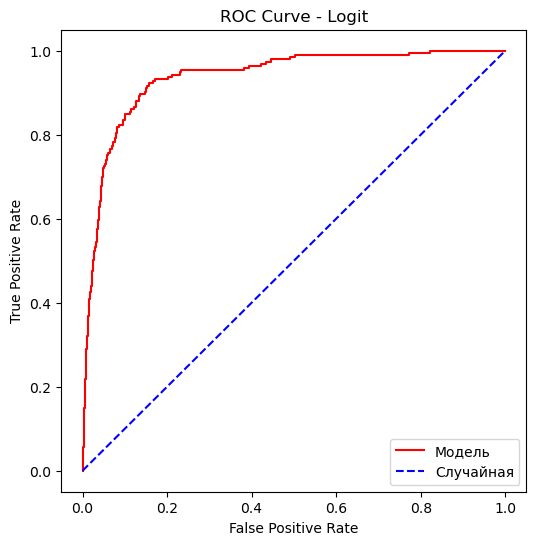

In [37]:
fpr, tpr, _ = roc_curve(y_test, y_test_pred1)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='red', label='Модель')
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label='Случайная')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logit")
plt.legend()
plt.show()



Создание графиков...


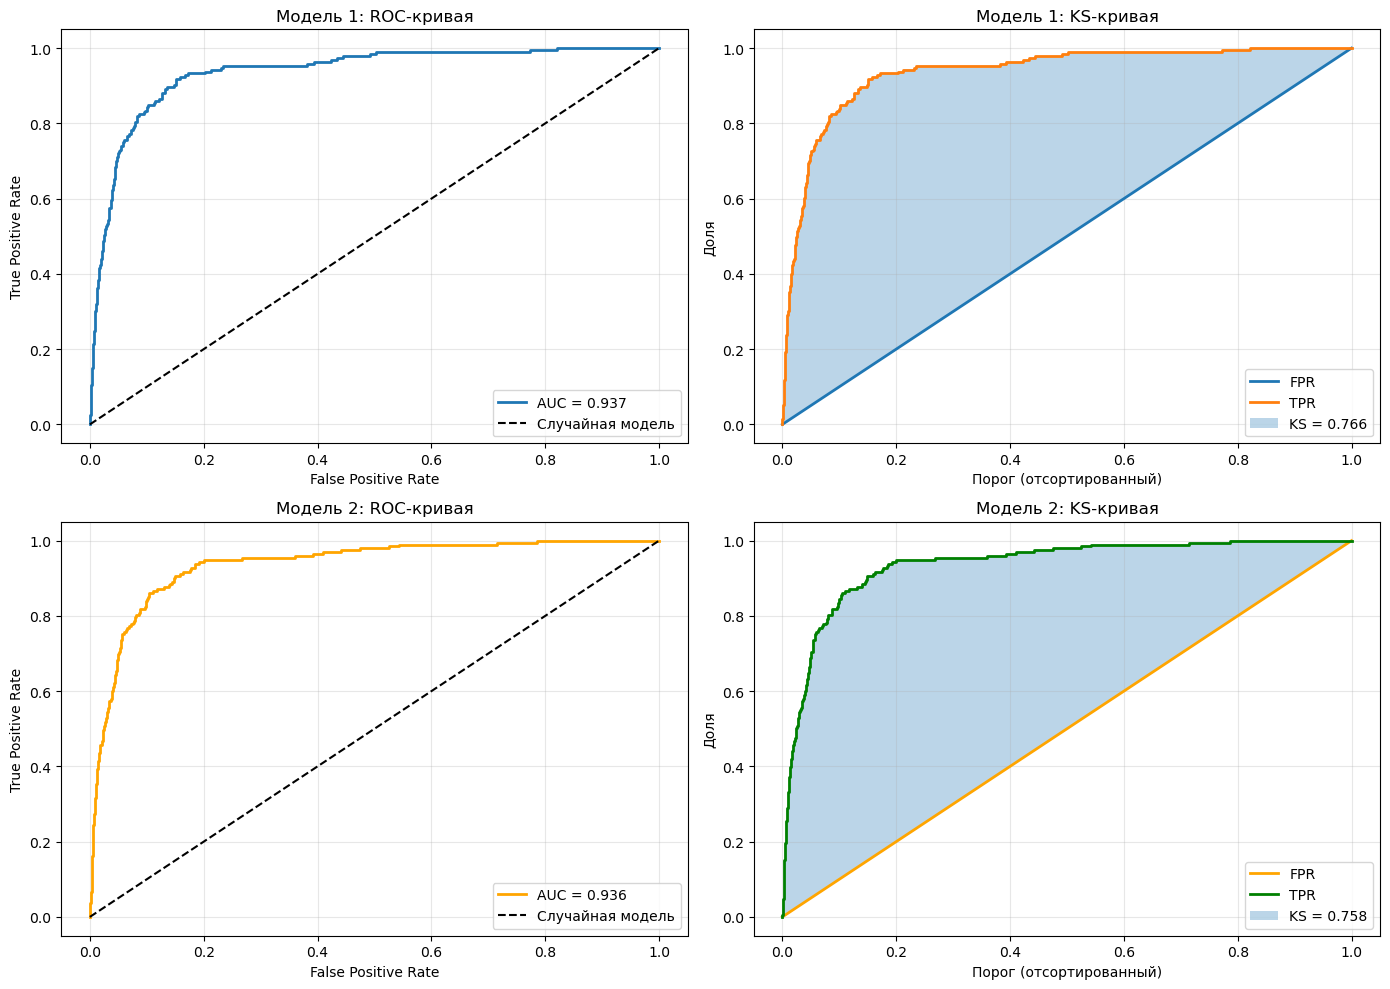

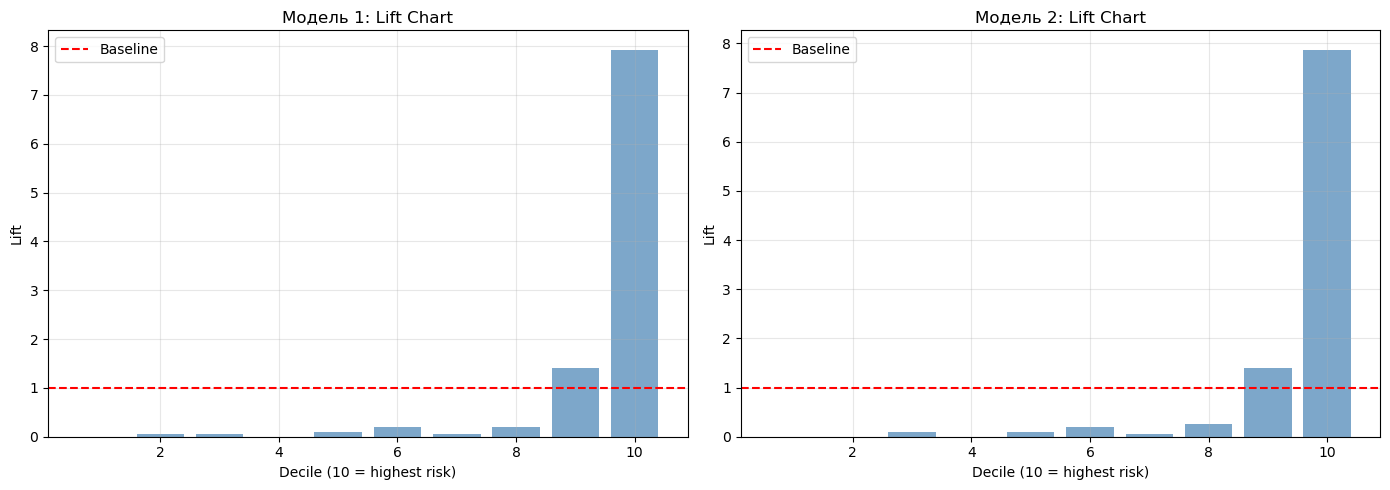

In [16]:
# ============================================================================
# ВИЗУАЛИЗАЦИЯ
# ============================================================================
print("\nСоздание графиков...")

# ROC и KS кривые
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Модель 1: ROC
fpr1, tpr1, _ = roc_curve(y_test, y_test_pred1)
axes[0, 0].plot(fpr1, tpr1, label=f'AUC = {metrics1_test["AUC"]:.3f}', lw=2)
axes[0, 0].plot([0, 1], [0, 1], 'k--', label='Случайная модель')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('Модель 1: ROC-кривая')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Модель 1: KS
axes[0, 1].plot(fpr1, fpr1, label='FPR', lw=2)
axes[0, 1].plot(fpr1, tpr1, label='TPR', lw=2)
axes[0, 1].fill_between(fpr1, tpr1, fpr1, alpha=0.3, label=f'KS = {metrics1_test["KS"]:.3f}')
axes[0, 1].set_xlabel('Порог (отсортированный)')
axes[0, 1].set_ylabel('Доля')
axes[0, 1].set_title('Модель 1: KS-кривая')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Модель 2: ROC
fpr2, tpr2, _ = roc_curve(y_test, y_test_pred2)
axes[1, 0].plot(fpr2, tpr2, label=f'AUC = {metrics2_test["AUC"]:.3f}', lw=2, color='orange')
axes[1, 0].plot([0, 1], [0, 1], 'k--', label='Случайная модель')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('Модель 2: ROC-кривая')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Модель 2: KS
axes[1, 1].plot(fpr2, fpr2, label='FPR', lw=2, color='orange')
axes[1, 1].plot(fpr2, tpr2, label='TPR', lw=2, color='green')
axes[1, 1].fill_between(fpr2, tpr2, fpr2, alpha=0.3, label=f'KS = {metrics2_test["KS"]:.3f}')
axes[1, 1].set_xlabel('Порог (отсортированный)')
axes[1, 1].set_ylabel('Доля')
axes[1, 1].set_title('Модель 2: KS-кривая')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()

# Lift Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def plot_lift_chart(y_true, y_pred, ax, title):
    """Построение Lift Chart"""
    df_lift = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
    df_lift = df_lift.sort_values('y_pred', ascending=False)
    df_lift['decile'] = pd.qcut(df_lift['y_pred'], q=10, labels=False, duplicates='drop') + 1
    
    lift_data = df_lift.groupby('decile').agg({
        'y_true': ['mean', 'count']
    }).reset_index()
    
    baseline = y_true.mean()
    lift_data['lift'] = lift_data['y_true']['mean'] / baseline
    
    ax.bar(lift_data['decile'], lift_data['lift'], color='steelblue', alpha=0.7)
    ax.axhline(y=1, color='red', linestyle='--', label='Baseline')
    ax.set_xlabel('Decile (10 = highest risk)')
    ax.set_ylabel('Lift')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plot_lift_chart(y_test, y_test_pred1, axes[0], 'Модель 1: Lift Chart')
plot_lift_chart(y_test, y_test_pred2, axes[1], 'Модель 2: Lift Chart')

plt.tight_layout()

plt.show()


АНАЛИЗ РАННЕГО ПРЕДУПРЕЖДЕНИЯ (EARLY WARNING SYSTEM)
Внимание: Колонка с годом определена автоматически как 'Год'
Анализ проводится по 193 ликвидированным компаниям из теста.

Модель: Модель 2 (с категориями)
Порог вероятности: 0.0317
----------------------------------------
Среднее время раннего обнаружения: 3.0 лет (до момента 'target=1')
Максимальный горизонт прогноза:    5 лет
Пропущено дефолтов (полностью):    10 компаний

Распределение (за сколько лет до фиксации проблем модель дала сигнал):
  За 1 лет: 28 компаний (14.5%)
  За 2 лет: 44 компаний (22.8%)
  За 3 лет: 45 компаний (23.3%)
  За 4 лет: 36 компаний (18.7%)
  За 5 лет: 30 компаний (15.5%)


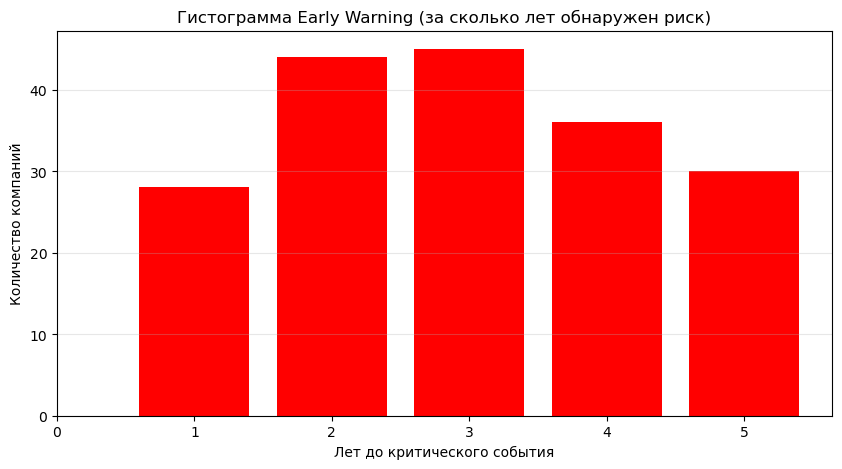

In [35]:
# %%
# ============================================================================
# 7. АНАЛИЗ EARLY WARNING (РАННЕЕ ПРЕДУПРЕЖДЕНИЕ)
# ============================================================================
print("\n" + "="*80)
print("АНАЛИЗ РАННЕГО ПРЕДУПРЕЖДЕНИЯ (EARLY WARNING SYSTEM)")
print("="*80)

# 1. Настройки
# УКАЖИТЕ ЗДЕСЬ НАЗВАНИЕ ВАШЕЙ КОЛОНКИ С ГОДОМ
year_col = 'Year'  # Например: 'year', 'god', 'report_year'
# Если колонки нет в test_data, попробуем найти похожую
if year_col not in test_data.columns:
    potential = [c for c in test_data.columns if 'year' in c.lower() or 'год' in c.lower()]
    if potential:
        year_col = potential[0]
        print(f"Внимание: Колонка с годом определена автоматически как '{year_col}'")
    else:
        print("ОШИБКА: Не найдена колонка года для временного анализа!")

# Используем прогнозы лучшей модели (Модель 2) и оптимальный порог
final_probs = y_test_pred2
final_threshold = threshold2  # Порог Youden из предыдущего шага

# Подготовка данных для анализа
ew_df = test_data.copy()
ew_df['prob'] = final_probs
ew_df['pred_risk'] = (ew_df['prob'] >= final_threshold).astype(int)

# Выбираем только компании, которые фактически ликвидировались в тестовой выборке
# (у которых target=1 хотя бы в одной записи)
# Примечание: предполагается, что target=1 стоит в год ПЕРЕД ликвидацией (next_year_liquidation)
liquidated_companies = ew_df[ew_df[target] == 1][group_col].unique()

print(f"Анализ проводится по {len(liquidated_companies)} ликвидированным компаниям из теста.")

early_warnings = []
missed_defaults = 0

for company in liquidated_companies:
    # Получаем всю историю компании, сортируем по годам
    comp_data = ew_df[ew_df[group_col] == company].sort_values(by=year_col)
    
    # Год, когда фактически сработал таргет (год перед ликвидацией)
    # Берем последний год с target=1 (обычно он один, но на всякий случай берем max)
    actual_crash_year = comp_data[comp_data[target] == 1][year_col].max()
    
    # Ищем годы, когда модель предсказала риск (prob > threshold)
    # Рассматриваем только предупреждения ДО или В ГОД краха
    warnings = comp_data[
        (comp_data['pred_risk'] == 1) & 
        (comp_data[year_col] <= actual_crash_year)
    ]
    
    if len(warnings) > 0:
        # Самое первое предупреждение
        first_warning_year = warnings[year_col].min()
        
        # Сколько лет запаса (включая текущий отчетный период)
        # Если target - это "ликвидация в след году", то (Crash Year - Warning Year) + 1 год запаса
        # Но чтобы соответствовать вашей логике "за сколько лет до":
        years_before = actual_crash_year - first_warning_year
        early_warnings.append(years_before)
    else:
        # Модель пропустила дефолт (False Negative на всей истории)
        missed_defaults += 1

early_warnings_1based = [x + 1 for x in early_warnings]
# Вывод результатов
print(f"\nМодель: Модель 2 (с категориями)")
print(f"Порог вероятности: {final_threshold:.4f}")
print("-" * 40)

if len(early_warnings_1based) > 0:
    mean_warning = np.mean(early_warnings_1based)
    max_warning = np.max(early_warnings_1based)
    
    print(f"Среднее время раннего обнаружения: {mean_warning:.1f} лет (до момента 'target=1')")
    print(f"Максимальный горизонт прогноза:    {max_warning} лет")
    print(f"Пропущено дефолтов (полностью):    {missed_defaults} компаний")
    
    print("\nРаспределение (за сколько лет до фиксации проблем модель дала сигнал):")
    # Подсчет частот
    max_years_plot = int(max_warning) + 1
    for i in range(max_years_plot):
        count = early_warnings_1based.count(i)
        if count > 0:
            # i=0 означает, что сигнал пришел в тот же год, когда проставлен target=1
            print(f"  За {i} лет: {count} компаний ({count/len(liquidated_companies):.1%})")
            
    # Визуализация
    plt.figure(figsize=(10, 5))
    plt.hist(early_warnings_1based, bins=range(1, int(max(early_warnings_1based))+2), align='left', rwidth=0.8, color='red', alpha=1)
    plt.title('Гистограмма Early Warning (за сколько лет обнаружен риск)')
    plt.xlabel('Лет до критического события')
    plt.ylabel('Количество компаний')
    plt.grid(axis='y', alpha=0.3)
    plt.xticks(range(int(max(early_warnings_1based))+1))
    plt.show()

else:
    print("Не найдено предупреждений или нет данных о годах.")

In [17]:
# ============================================================================
# ВЫВОДЫ
# ============================================================================
print("\n" + "="*80)
print("КРАТКИЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ")
print("="*80)

print(f"""
1. СРАВНЕНИЕ МОДЕЛЕЙ:
   Модель 2 (с категориальными признаками) показывает лучшие результаты с AUC={metrics2_test['AUC']:.3f} 
   против {metrics1_test['AUC']:.3f} у Модели 1. Включение топ-10 рискованных регионов и отраслей 
   значимо улучшило дискриминационную способность модели (прирост Gini на {(metrics2_test['Gini']-metrics1_test['Gini']):.3f}).

2. КЛЮЧЕВЫЕ ФАКТОРЫ РИСКА:
   Наиболее значимыми предикторами ликвидации оказались: {coef_table2.head(3)['Feature'].tolist()}.
   Финансовые коэффициенты ликвидности и рентабельности, а также региональная принадлежность 
   имеют наибольшее влияние на вероятность дефолта.

3. КАЛИБРОВКА И ВАЛИДНОСТЬ:
   Тест Хосмера-Лемешева показал p-value={hl2_p:.3f} для Модели 2, что {'подтверждает' if hl2_p > 0.05 else 'ставит под вопрос'}
   хорошую калибровку модели. KS-статистика {metrics2_test['KS']:.3f} указывает на {'отличную' if metrics2_test['KS'] > 0.4 else 'приемлемую'} 
   разделяющую способность.

4. РЕКОМЕНДУЕМЫЙ ПОРОГ:
   Оптимальный порог отсечения по критерию Youden составляет {threshold2:.3f}. При таком пороге 
   ожидаемый уровень дефолта в группе риска составит примерно {y_test[y_test_pred2 >= threshold2].mean():.1%}.

5. ГОТОВНОСТЬ К ВНЕДРЕНИЮ:
   Модель 2 готова к внедрению в риск-менеджмент с оговоркой на необходимость регулярного 
   мониторинга и рекалибровки. Рекомендуется установить процедуру ежеквартального пересмотра 
   модели и валидации на новых данных для поддержания предсказательной силы.
""")

print("="*80)
print("АНАЛИЗ ЗАВЕРШЕН")
print("="*80)


КРАТКИЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ

1. СРАВНЕНИЕ МОДЕЛЕЙ:
   Модель 2 (с категориальными признаками) показывает лучшие результаты с AUC=0.936 
   против 0.937 у Модели 1. Включение топ-10 рискованных регионов и отраслей 
   значимо улучшило дискриминационную способность модели (прирост Gini на -0.001).

2. КЛЮЧЕВЫЕ ФАКТОРЫ РИСКА:
   Наиболее значимыми предикторами ликвидации оказались: ['Коэффициент текущей ликвидности, %', 'Выручка, RUB', 'Коэффициент быстрой ликвидности, %'].
   Финансовые коэффициенты ликвидности и рентабельности, а также региональная принадлежность 
   имеют наибольшее влияние на вероятность дефолта.

3. КАЛИБРОВКА И ВАЛИДНОСТЬ:
   Тест Хосмера-Лемешева показал p-value=0.002 для Модели 2, что ставит под вопрос
   хорошую калибровку модели. KS-статистика 0.758 указывает на отличную 
   разделяющую способность.

4. РЕКОМЕНДУЕМЫЙ ПОРОГ:
   Оптимальный порог отсечения по критерию Youden составляет 0.032. При таком пороге 
   ожидаемый уровень дефолта в группе риска состави

In [ ]:


#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [19]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [20]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 2")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred2)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred2):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred2)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred2)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred2 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 2
AUC-ROC: 0.9365
Gini коэффициент: 0.8729
KS-статистика: 0.7577
Порог для KS: 0.0317

Матрица ошибок (порог = KS):
[[5280  925]
 [  18  175]]

Accuracy: 0.8526
Precision: 0.1591
Recall (Sensitivity): 0.9067
Specificity: 0.8509
F1-Score: 0.2707


In [21]:
"""
Расчет метрик качества модели на уровне компаний
(агрегация наблюдений по каждой компании)
"""

import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ НА УРОВНЕ КОМПАНИЙ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1 (НА УРОВНЕ КОМПАНИЙ)")
print("=" * 80)

# Создание DataFrame с результатами на тестовой выборке
test_results = pd.DataFrame({
    'company_id': test_data[group_col].values,  # Регистрационный номер
    'y_true': y_test.values,
    'y_pred_proba': y_test_pred1
})

# Агрегация по компаниям
# Для каждой компании берем среднюю предсказанную вероятность
# и максимальное значение факта дефолта (если хотя бы раз был дефолт)
company_level = test_results.groupby('company_id').agg({
    'y_true': 'max',  # Была ли ликвидация компании (1, если хотя бы раз)
    'y_pred_proba': 'mean'  # Средняя предсказанная вероятность по всем наблюдениям
}).reset_index()

print(f"\nКоличество уникальных компаний в тесте: {len(company_level)}")
print(f"Доля компаний с ликвидацией: {company_level['y_true'].mean():.2%}")

# Извлечение данных на уровне компаний
y_test_company = company_level['y_true'].values
y_pred_company = company_level['y_pred_proba'].values

# ROC-AUC на уровне компаний
auc_score = roc_auc_score(y_test_company, y_pred_company)
gini = 2 * auc_score - 1

print(f"\nAUC-ROC (компании): {auc_score:.4f}")
print(f"Gini коэффициент (компании): {gini:.4f}")

# KS-статистика на уровне компаний
def ks_statistic(y_true, y_pred_proba):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test_company, y_pred_company)
print(f"KS-статистика (компании): {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_pred_company >= ks_thresh).astype(int)
cm = confusion_matrix(y_test_company, y_pred_ks)

print("\nМатрица ошибок на уровне компаний (порог = KS):")
print(f"                Predicted 0  Predicted 1")
print(f"Actual 0 (TN)   {cm[0, 0]:>11}  {cm[0, 1]:>11} (FP)")
print(f"Actual 1 (FN)   {cm[1, 0]:>11}  {cm[1, 1]:>11} (TP)")

# Детальные метрики на уровне компаний
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n--- Метрики классификации (уровень компаний) ---")
print(f"Accuracy: {accuracy:.4f}  ({accuracy:.1%})")
print(f"Precision: {precision:.4f}  (из предсказанных дефолтов - реально дефолтнули)")
print(f"Recall (Sensitivity): {recall:.4f}  (из реальных дефолтов - поймали)")
print(f"Specificity: {specificity:.4f}  (из реальных не-дефолтов - правильно определили)")
print(f"F1-Score: {f1:.4f}")

# Дополнительные метрики
print(f"\n--- Интерпретация ---")
print(f"Всего компаний в тесте: {len(company_level)}")
print(f"Компаний с ликвидацией: {int(y_test_company.sum())}")
print(f"Правильно определено дефолтов: {tp} из {tp + fn} ({recall:.1%})")
print(f"Ложных тревог (FP): {fp} ({fp / len(company_level):.1%} от всех компаний)")
print(f"Пропущено дефолтов (FN): {fn} ({fn / (tp + fn) * 100 if (tp + fn) > 0 else 0:.1f}%)")

#=================================================================================
# СРАВНЕНИЕ: МЕТРИКИ НА УРОВНЕ НАБЛЮДЕНИЙ vs УРОВНЕ КОМПАНИЙ
#=================================================================================

print("\n" + "=" * 80)
print("СРАВНЕНИЕ: НАБЛЮДЕНИЯ vs КОМПАНИИ")
print("=" * 80)

# Метрики на уровне наблюдений (для сравнения)
auc_obs = roc_auc_score(y_test, y_test_pred1)
ks_obs, _ = ks_statistic(y_test, y_test_pred1)

print(f"\n{'Метрика':<30} {'Наблюдения':>15} {'Компании':>15} {'Разница':>15}")
print("-" * 80)
print(f"{'AUC-ROC':<30} {auc_obs:>15.4f} {auc_score:>15.4f} {auc_score - auc_obs:>15.4f}")
print(f"{'Gini':<30} {2*auc_obs - 1:>15.4f} {gini:>15.4f} {gini - (2*auc_obs - 1):>15.4f}")
print(f"{'KS-статистика':<30} {ks_obs:>15.4f} {ks_stat:>15.4f} {ks_stat - ks_obs:>15.4f}")

print("\n" + "=" * 80)

#=================================================================================
# АЛЬТЕРНАТИВНЫЕ МЕТОДЫ АГРЕГАЦИИ (ОПЦИОНАЛЬНО)
#=================================================================================

print("\nДОПОЛНИТЕЛЬНО: Альтернативные методы агрегации по компаниям:")
print("-" * 80)

# Метод 1: Максимальная вероятность (worst case)
company_max = test_results.groupby('company_id').agg({
    'y_true': 'max',
    'y_pred_proba': 'max'  # Максимальный риск по всем наблюдениям
}).reset_index()

auc_max = roc_auc_score(company_max['y_true'], company_max['y_pred_proba'])
print(f"1. Максимальная вероятность: AUC = {auc_max:.4f}")

# Метод 2: Последнее наблюдение компании (если есть временная последовательность)
company_last = test_results.groupby('company_id').tail(1)
if len(company_last) == len(company_level):
    auc_last = roc_auc_score(company_last['y_true'], company_last['y_pred_proba'])
    print(f"2. Последнее наблюдение: AUC = {auc_last:.4f}")

# Метод 3: Медианная вероятность
company_median = test_results.groupby('company_id').agg({
    'y_true': 'max',
    'y_pred_proba': 'median'
}).reset_index()

auc_median = roc_auc_score(company_median['y_true'], company_median['y_pred_proba'])
print(f"3. Медианная вероятность: AUC = {auc_median:.4f}")

print("\nРекомендуется использовать среднюю вероятность для сбалансированной оценки.")
print("=" * 80)


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1 (НА УРОВНЕ КОМПАНИЙ)

Количество уникальных компаний в тесте: 1590
Доля компаний с ликвидацией: 12.14%

AUC-ROC (компании): 0.9484
Gini коэффициент (компании): 0.8967
KS-статистика (компании): 0.7714
Порог для KS: 0.0345

Матрица ошибок на уровне компаний (порог = KS):
                Predicted 0  Predicted 1
Actual 0 (TN)          1302           95 (FP)
Actual 1 (FN)            31          162 (TP)

--- Метрики классификации (уровень компаний) ---
Accuracy: 0.9208  (92.1%)
Precision: 0.6304  (из предсказанных дефолтов - реально дефолтнули)
Recall (Sensitivity): 0.8394  (из реальных дефолтов - поймали)
Specificity: 0.9320  (из реальных не-дефолтов - правильно определили)
F1-Score: 0.7200

--- Интерпретация ---
Всего компаний в тесте: 1590
Компаний с ликвидацией: 193
Правильно определено дефолтов: 162 из 193 (83.9%)
Ложных тревог (FP): 95 (6.0% от всех компаний)
Пропущено дефолтов (FN): 31 (16.1%)

СРАВНЕНИЕ: НАБЛЮДЕНИЯ vs КОМПАНИИ

Метрика                    

In [25]:
# %%
# ============================================================================
# 8. ИТОГОВОЕ СРАВНЕНИЕ (PRECISION & RECALL)
# ============================================================================
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

print("\n" + "="*80)
print("СРАВНЕНИЕ МОДЕЛЕЙ ПО БИЗНЕС-МЕТРИКАМ")
print("="*80)

# Функция для расчета метрик при оптимальном пороге
def get_business_metrics(y_true, y_prob, threshold):
    y_pred_bin = (y_prob >= threshold).astype(int)
    return {
        'Threshold': threshold,
        'AUC': roc_auc_score(y_true, y_prob),
        'Precision': precision_score(y_true, y_pred_bin),
        'Recall': recall_score(y_true, y_pred_bin),
        'F1': f1_score(y_true, y_pred_bin),
        'Accuracy': accuracy_score(y_true, y_pred_bin)
    }

# Расчет для обеих моделей (используем ранее найденные пороги Youden)
metrics_m1 = get_business_metrics(y_test, y_test_pred1, threshold1)
metrics_m2 = get_business_metrics(y_test, y_test_pred2, threshold2)

# Создание сводной таблицы
comparison_df = pd.DataFrame([metrics_m1, metrics_m2], index=['Модель 1 (Числовые)', 'Модель 2 (+Категории)'])

print("\nСравнительная таблица (на тестовой выборке):")
print("-" * 100)
# Форматирование вывода
pd.options.display.float_format = '{:.4f}'.format
print(comparison_df[['AUC', 'Precision', 'Recall', 'F1', 'Threshold']])
print("-" * 100)

print("\nИНТЕРПРЕТАЦИЯ:")
best_recall = comparison_df['Recall'].max()
best_prec = comparison_df.loc[comparison_df['Recall'].idxmax()]['Precision'] # Precision лучшей по Recall модели

print(f"1. ПОЛНОТА (Recall): Модель 2 обнаруживает {metrics_m2['Recall']:.1%} проблемных компаний.")
print(f"   (Это значит, что мы пропускаем {(1-metrics_m2['Recall']):.1%} дефолтов).")

print(f"2. ТОЧНОСТЬ (Precision): У Модели 2 точность {metrics_m2['Precision']:.1%}.")
print(f"   (Из 100 компаний, помеченных как 'рискованные', реально закрываются {int(metrics_m2['Precision']*100)}).")

print(f"3. БАЛАНС: F1-score (гармоническое среднее) вырос с {metrics_m1['F1']:.3f} до {metrics_m2['F1']:.3f}.")

diff_recall = metrics_m2['Recall'] - metrics_m1['Recall']
if diff_recall > 0:
    print(f"\nВЫВОД: Добавление категориальных признаков позволило найти на {diff_recall:.1%} больше дефолтов")
    print("при сопоставимом или лучшем уровне ложных срабатываний.")
else:
    print("\nВЫВОД: Категориальные признаки не дали прироста в охвате дефолтов.")


СРАВНЕНИЕ МОДЕЛЕЙ ПО БИЗНЕС-МЕТРИКАМ

Сравнительная таблица (на тестовой выборке):
----------------------------------------------------------------------------------------------------
                         AUC  Precision  Recall     F1  Threshold
Модель 1 (Числовые)   0.9368     0.1586  0.9171 0.2704     0.0327
Модель 2 (+Категории) 0.9365     0.1591  0.9067 0.2707     0.0317
----------------------------------------------------------------------------------------------------

ИНТЕРПРЕТАЦИЯ:
1. ПОЛНОТА (Recall): Модель 2 обнаруживает 90.7% проблемных компаний.
   (Это значит, что мы пропускаем 9.3% дефолтов).
2. ТОЧНОСТЬ (Precision): У Модели 2 точность 15.9%.
   (Из 100 компаний, помеченных как 'рискованные', реально закрываются 15).
3. БАЛАНС: F1-score (гармоническое среднее) вырос с 0.270 до 0.271.

ВЫВОД: Категориальные признаки не дали прироста в охвате дефолтов.
